# Does representative normal-reference selection help?

This notebook reads saved PCB1 results and figures. It does not load raw images,
pretrained weights or memory arrays; it does not perform feature extraction,
selection, calibration or anomaly inference. PCB2 remains sealed.

The original frozen pilot is retained. C1/C2 are the completed uniform-memory
geometry experiments at 256/512. D1/D2 substitute one full-population projected
approximate greedy selector at the same 4,096-reference count. All subsequent PCB1
outcomes are development evidence, not a fresh confirmatory test.

Read the accompanying findings and journey chapter for the engineering decision.
This notebook intentionally presents every declared outcome, including regressions.

In [1]:
from pathlib import Path
import hashlib,json
import pandas as pd
from IPython.display import display,Image
root=Path.cwd()
if not (root/'artifacts').exists():root=root.parent
folder=root/'artifacts/pcb1_memory_selection_comparison'
metadata=json.loads((folder/'comparison_metadata.json').read_text())
assert metadata['new_model_inference'] is False and metadata['pcb2_exposed'] is False
for name,expected in metadata['outputs'].items():
 assert hashlib.sha256((folder/name).read_bytes()).hexdigest()==expected
for family in ['geometry','coreset']:
 for size in [256,512]:
  path=root/f'artifacts/runs/{family}_{size}_v1'
  review=json.loads((path/'independent_review.json').read_text())
  assert review['passed']
  assert review['complete_sha256']==hashlib.sha256((path/'complete.json').read_bytes()).hexdigest()
print('Saved comparison artifacts verified; all four development reviews passed.')

Saved comparison artifacts verified; all four development reviews passed.


## One controlled substitution

Both resolutions use frozen ResNet18 layer2/layer3 features, 3×3 neighborhood pooling,
direct Euclidean nearest-reference distance in 384 dimensions, maximum-patch image
scoring, all-patch eligibility including padding boundaries, and the existing
crop/letterbox geometry. No orientation registration was added.

Selection alone uses a seeded Gaussian 384→64 projection. Ten fitting-normal anchors
initialize mean Euclidean distances; farthest-first updates retain minimum distance
to each selected center. The full fitting patch population remains eligible.
Projection is not used for anomaly scoring. The algorithm remains PatchCore-inspired.

Each new bank is recalibrated from the same 181 normal images using 95th/99th
`higher` quantiles and strict `>` decisions. Numeric thresholds are not reused.

,recipe,size,selector,image_threshold,pixel_threshold,image_ap,auroc,recall,fpr,tp,...,fn,tn,median_pixel_ap,pooled_pixel_ap,iou,peak_inside_count,overlap_count,source_median_pixel_ap,inference_median_seconds,inference_p95_seconds
0,Run1 direct256,256,original,2.400070,1.815792,0.851568,0.8654,0.43,0.09,43,...,57,91,0.039337,0.791977,0.121817,26,79,NaN,0.306921,0.335487
1,C1 uniform256,256,uniform,2.260681,1.720522,0.905606,0.9082,0.61,0.04,61,...,39,96,0.096820,0.813358,0.118186,30,92,0.091931,0.291909,0.293628
2,C2 uniform512,512,uniform,2.716464,1.910818,0.903110,0.9133,0.70,0.12,70,...,30,88,0.353520,0.686319,0.127311,50,98,0.352321,1.080967,1.100750
3,D1 coreset256,256,coreset,1.783695,1.465826,0.968047,0.9731,0.89,0.04,89,...,11,96,0.352906,0.845198,0.115343,49,99,0.349564,0.290946,0.296383
4,D2 coreset512,512,coreset,2.028992,1.665418,0.975981,0.9782,0.95,0.11,95,...,5,89,0.534820,0.829973,0.141107,71,98,0.533689,1.080720,1.137649


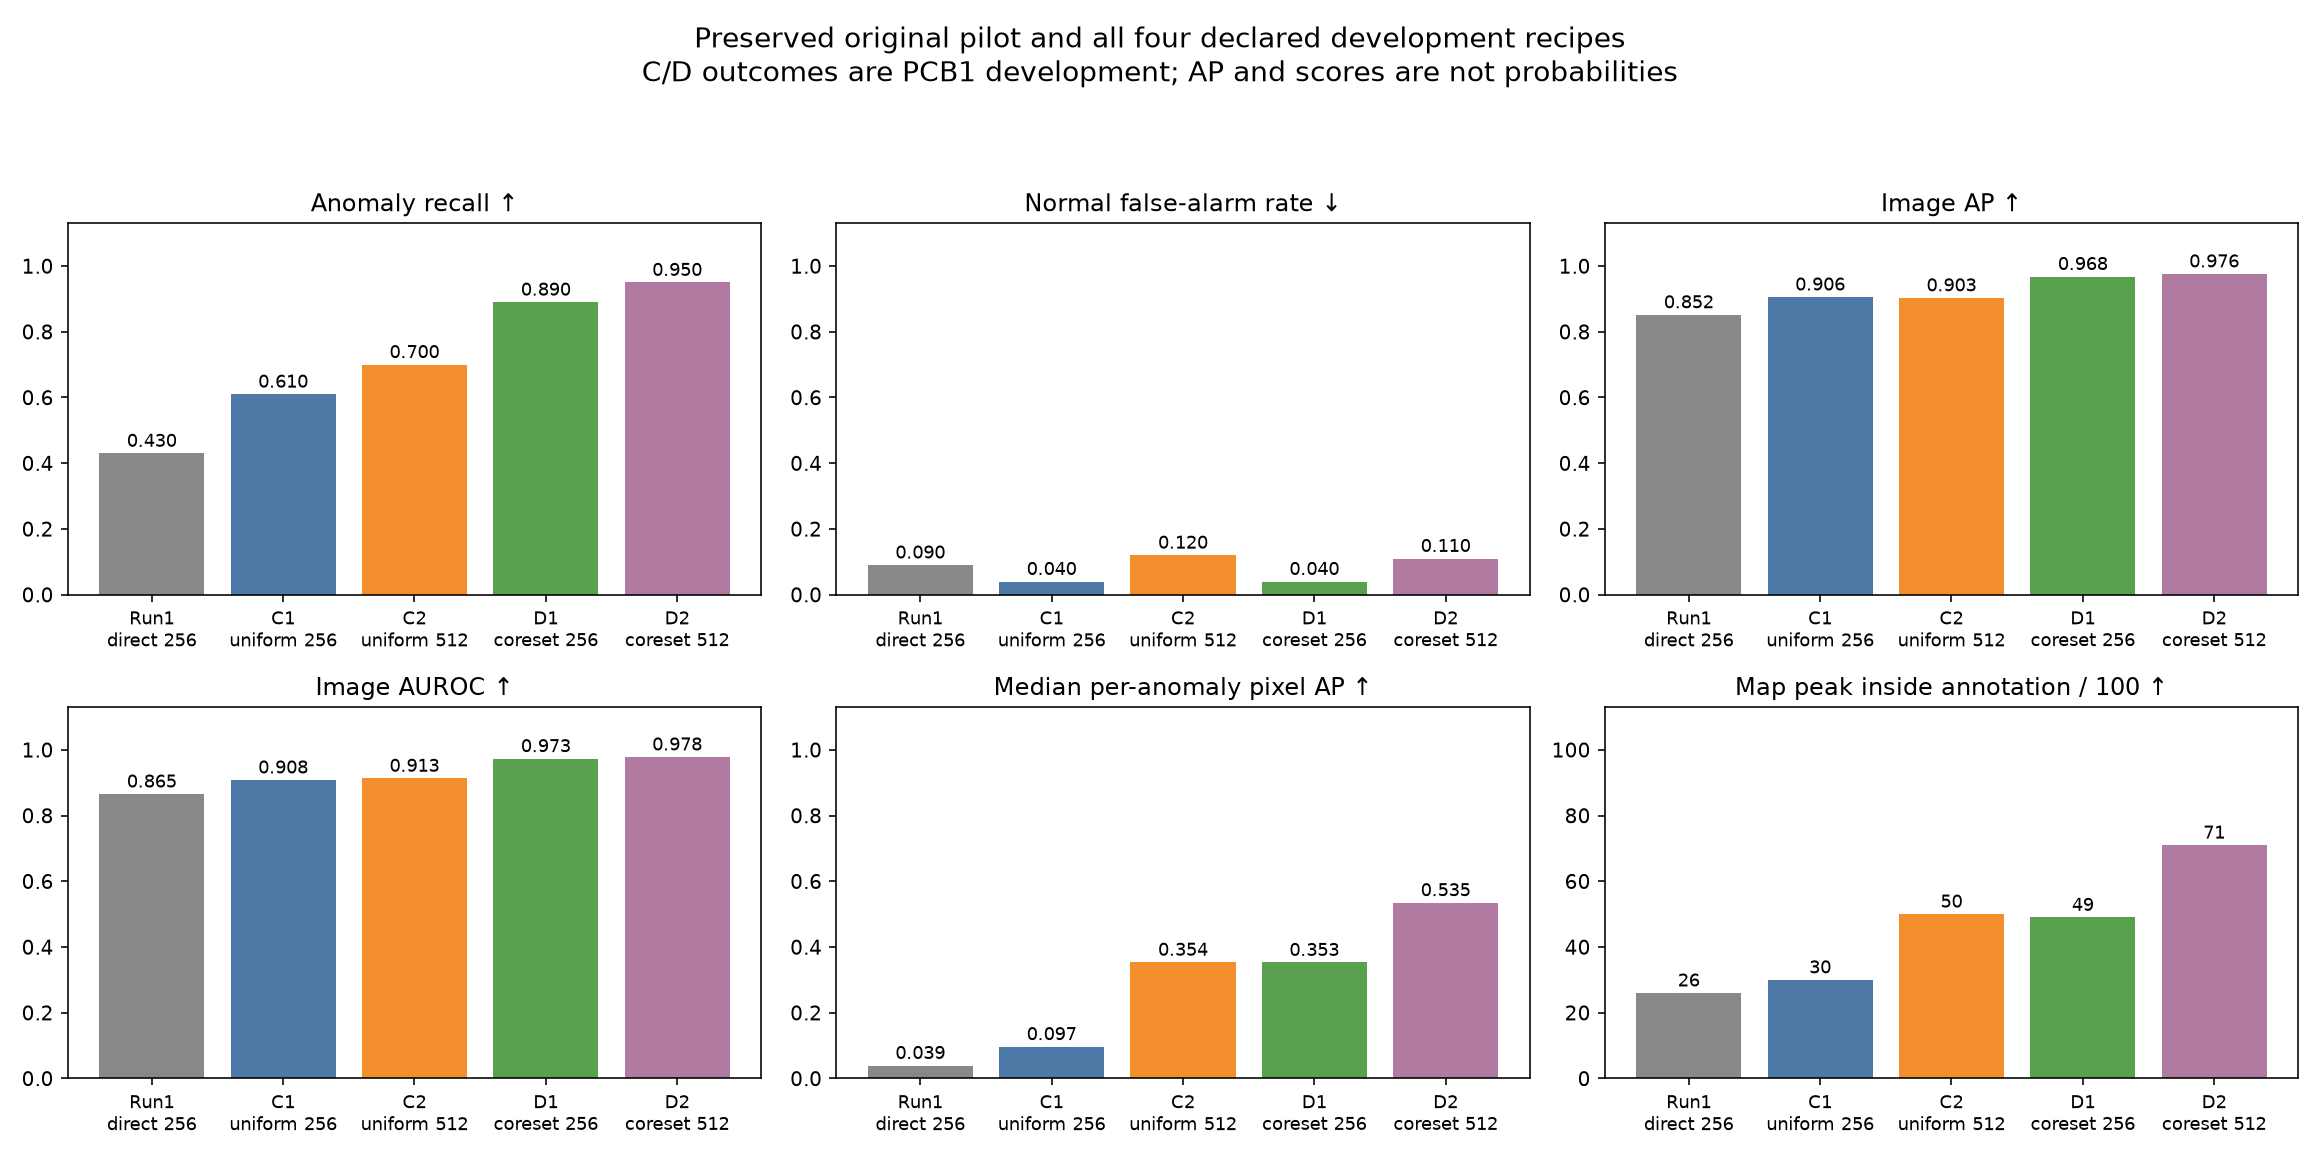

,control,revised,metric,control_value,revised_value,difference_revised_minus_control,preferred_direction
0,C1 uniform256,D1 coreset256,recall,0.610000,0.890000,0.280000,higher
1,C1 uniform256,D1 coreset256,fpr,0.040000,0.040000,0.000000,lower
2,C1 uniform256,D1 coreset256,image_ap,0.905606,0.968047,0.062440,higher
3,C1 uniform256,D1 coreset256,auroc,0.908200,0.973100,0.064900,higher
4,C1 uniform256,D1 coreset256,median_pixel_ap,0.096820,0.352906,0.256086,higher
5,C1 uniform256,D1 coreset256,peak_inside_count,30.000000,49.000000,19.000000,higher
6,C2 uniform512,D2 coreset512,recall,0.700000,0.950000,0.250000,higher
7,C2 uniform512,D2 coreset512,fpr,0.120000,0.110000,-0.010000,lower
8,C2 uniform512,D2 coreset512,image_ap,0.903110,0.975981,0.072872,higher
9,C2 uniform512,D2 coreset512,auroc,0.913300,0.978200,0.064900,higher


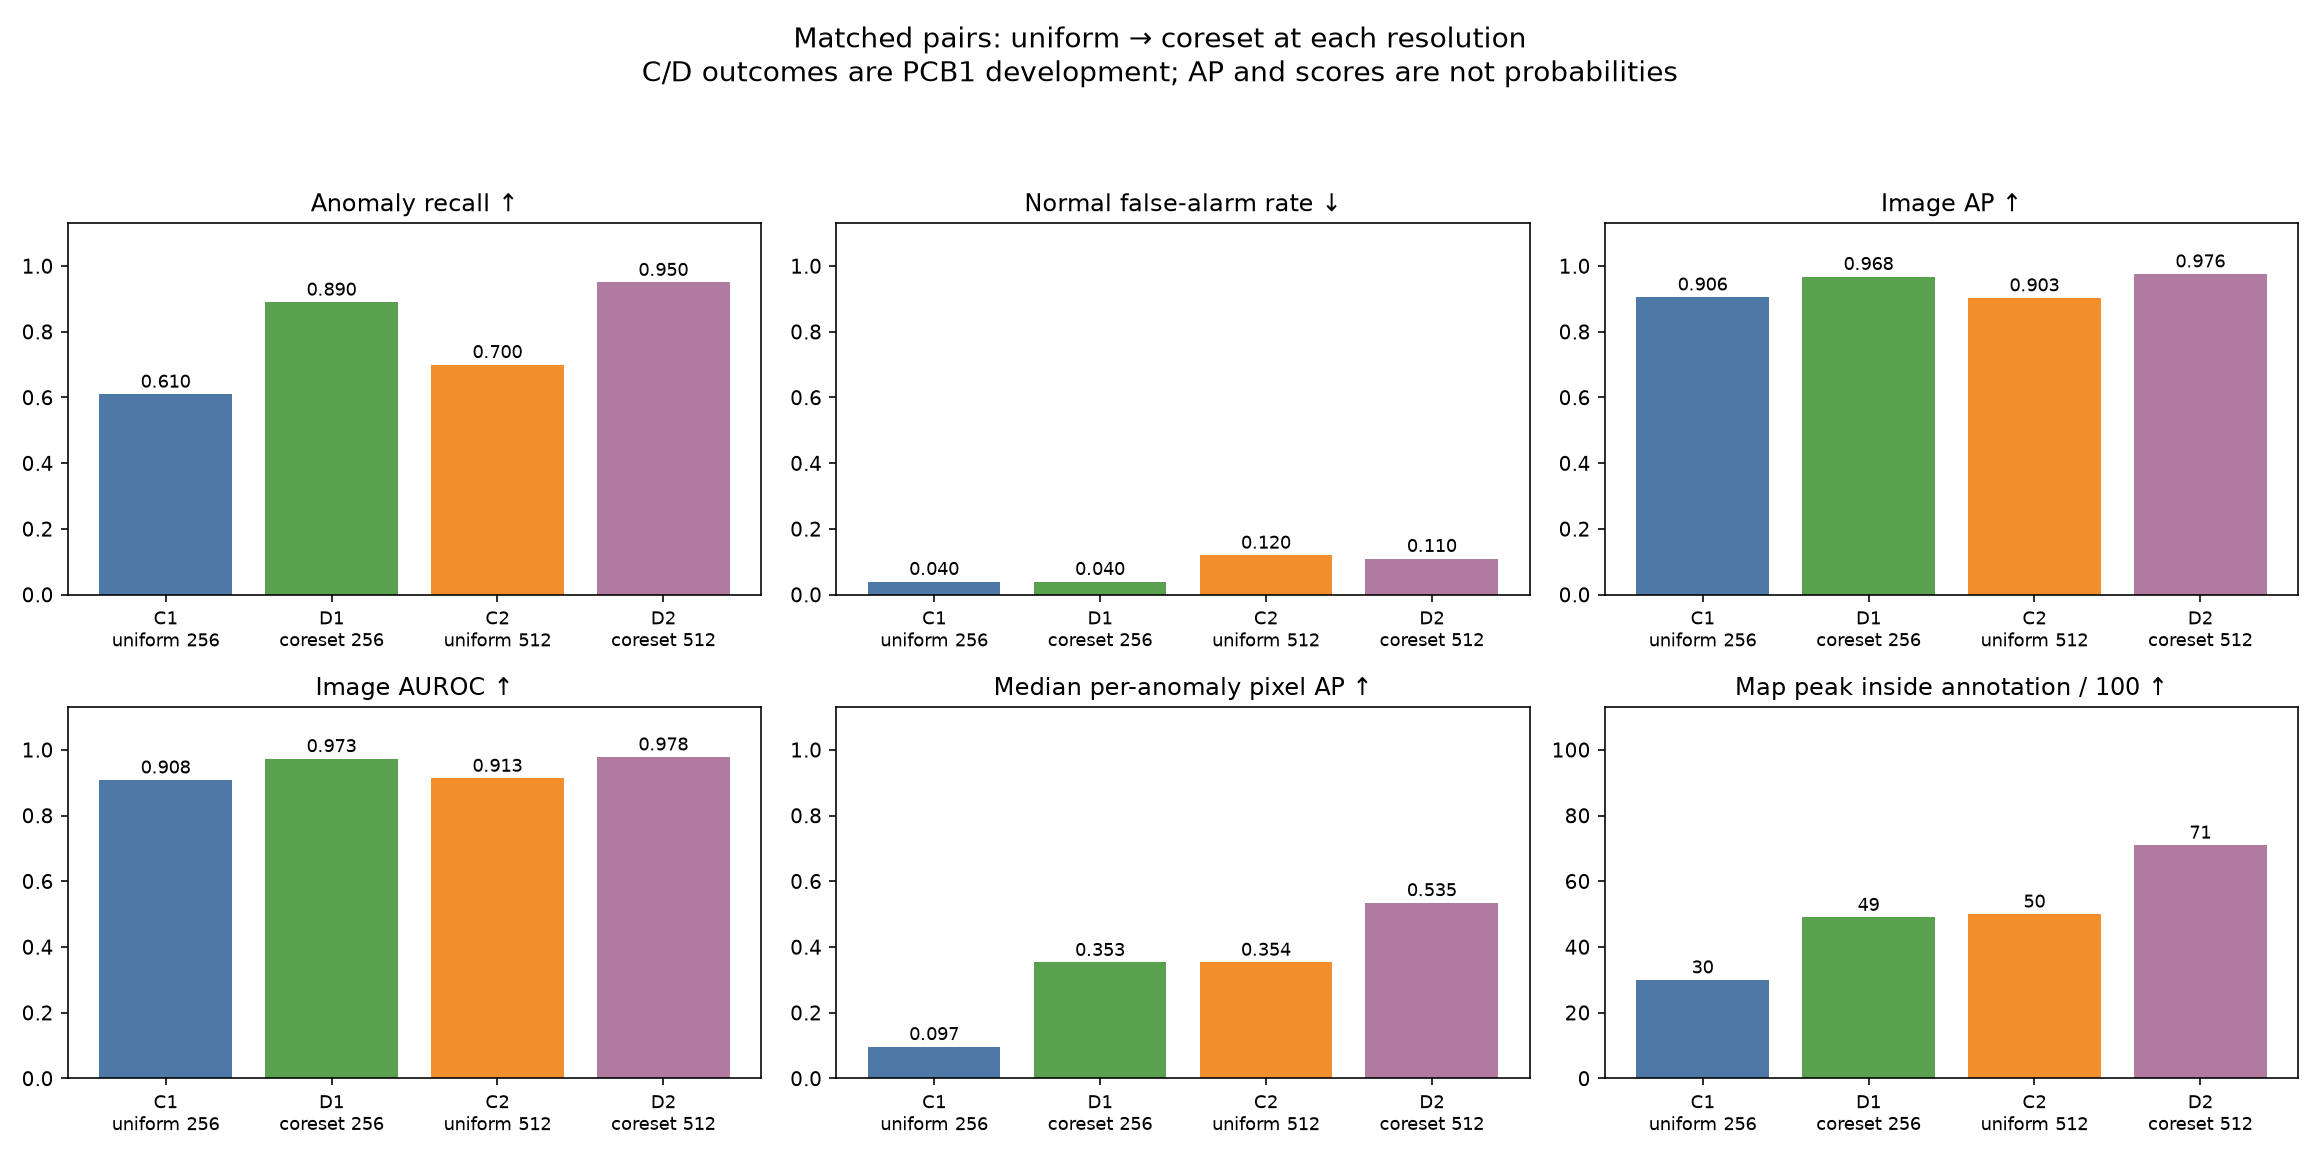

In [2]:
display(pd.read_csv(folder/'comparison.csv'))
display(Image(filename=str(folder/'journey.png')))
display(pd.read_csv(folder/'matched_pair_changes.csv'))
display(Image(filename=str(folder/'matched_pairs.png')))

## Detection and localization must be read together

Normal false-alarm rate is better when lower. Recall alone omits review burden.
AP and AUROC describe ranking; anomaly scores and heatmap ratios are not calibrated
probabilities. Pooled common 256 pixel AP includes all 200 images. Per-image medians
include all 100 anomalies and can reveal weaknesses hidden by pooling.

Maps are inverse-mapped into the entire source frame, with outside-crop scores
zero, before common 256 evaluation. Ground truth is nearest-resized directly from
the source and is never cropped to the prediction region. Source-resolution
per-image metrics are supporting views with different denominators.

,defect_type,sample_count,detected_count,missed_count,recall,mask_area_fraction_min,mask_area_fraction_max,median_image_anomaly_score,median_score_minus_threshold,median_pixel_ap,peak_inside_mask_rate,overlap_rate,recipe,median_source_pixel_ap
0,bent,15,12,3.0,0.800000,0.000992,0.003738,2.715506,0.315436,0.210754,0.466667,1.000000,Run1 direct256,NaN
1,melt,54,19,35.0,0.351852,0.000793,0.018723,2.356254,-0.043816,0.017411,0.111111,0.666667,Run1 direct256,NaN
2,missing,20,14,6.0,0.700000,0.001114,0.127228,3.107752,0.707682,0.939275,0.650000,0.900000,Run1 direct256,NaN
3,scratch,21,3,18.0,0.142857,0.001404,0.049576,2.336626,-0.063444,0.015982,0.190476,0.904762,Run1 direct256,NaN
4,bent,15,15,NaN,1.000000,NaN,NaN,NaN,NaN,0.242518,NaN,NaN,C1 uniform256,0.220318
5,melt,54,25,NaN,0.462963,NaN,NaN,NaN,NaN,0.047320,NaN,NaN,C1 uniform256,0.045735
6,missing,20,16,NaN,0.800000,NaN,NaN,NaN,NaN,0.963504,NaN,NaN,C1 uniform256,0.963664
7,scratch,21,11,NaN,0.523810,NaN,NaN,NaN,NaN,0.040661,NaN,NaN,C1 uniform256,0.037070
8,bent,15,14,NaN,0.933333,NaN,NaN,NaN,NaN,0.371140,NaN,NaN,C2 uniform512,0.375424
9,melt,54,35,NaN,0.648148,NaN,NaN,NaN,NaN,0.338296,NaN,NaN,C2 uniform512,0.320990


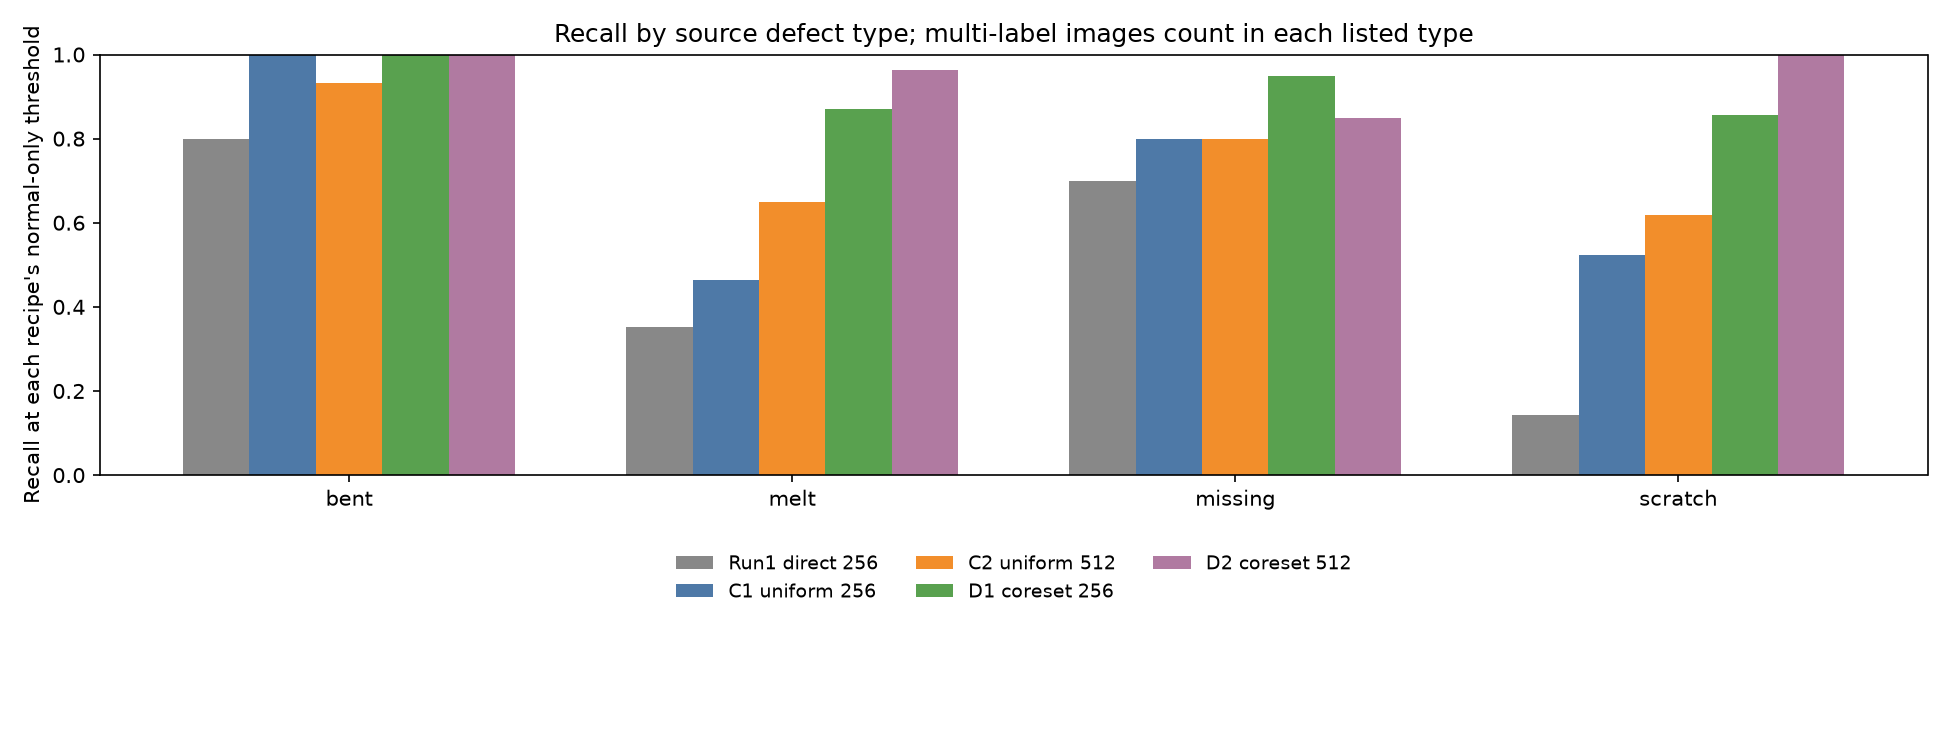

,size_quartile,sample_count,detected_count,missed_count,recall,mask_area_fraction_min,mask_area_fraction_max,median_image_anomaly_score,median_score_minus_threshold,median_pixel_ap,peak_inside_mask_rate,overlap_rate,recipe,median_source_pixel_ap
0,Q1,27,9,18.0,0.333333,0.000793,0.001495,2.332686,-0.067384,0.007902,0.037037,0.629630,Run1 direct256,NaN
1,Q2,24,7,17.0,0.291667,0.001556,0.001999,2.359280,-0.040790,0.016473,0.125000,0.708333,Run1 direct256,NaN
2,Q3,25,10,15.0,0.400000,0.002014,0.003143,2.336626,-0.063444,0.040959,0.240000,0.840000,Run1 direct256,NaN
3,Q4,24,17,7.0,0.708333,0.003494,0.127228,3.092181,0.692111,0.763473,0.666667,1.000000,Run1 direct256,NaN
4,Q1,27,14,NaN,0.518519,NaN,NaN,NaN,NaN,0.023146,NaN,NaN,C1 uniform256,0.023181
5,Q2,24,15,NaN,0.625000,NaN,NaN,NaN,NaN,0.067826,NaN,NaN,C1 uniform256,0.065802
6,Q3,25,14,NaN,0.560000,NaN,NaN,NaN,NaN,0.092681,NaN,NaN,C1 uniform256,0.086790
7,Q4,24,18,NaN,0.750000,NaN,NaN,NaN,NaN,0.808623,NaN,NaN,C1 uniform256,0.808164
8,Q1,27,16,NaN,0.592593,NaN,NaN,NaN,NaN,0.202794,NaN,NaN,C2 uniform512,0.183343
9,Q2,24,18,NaN,0.750000,NaN,NaN,NaN,NaN,0.228711,NaN,NaN,C2 uniform512,0.220864


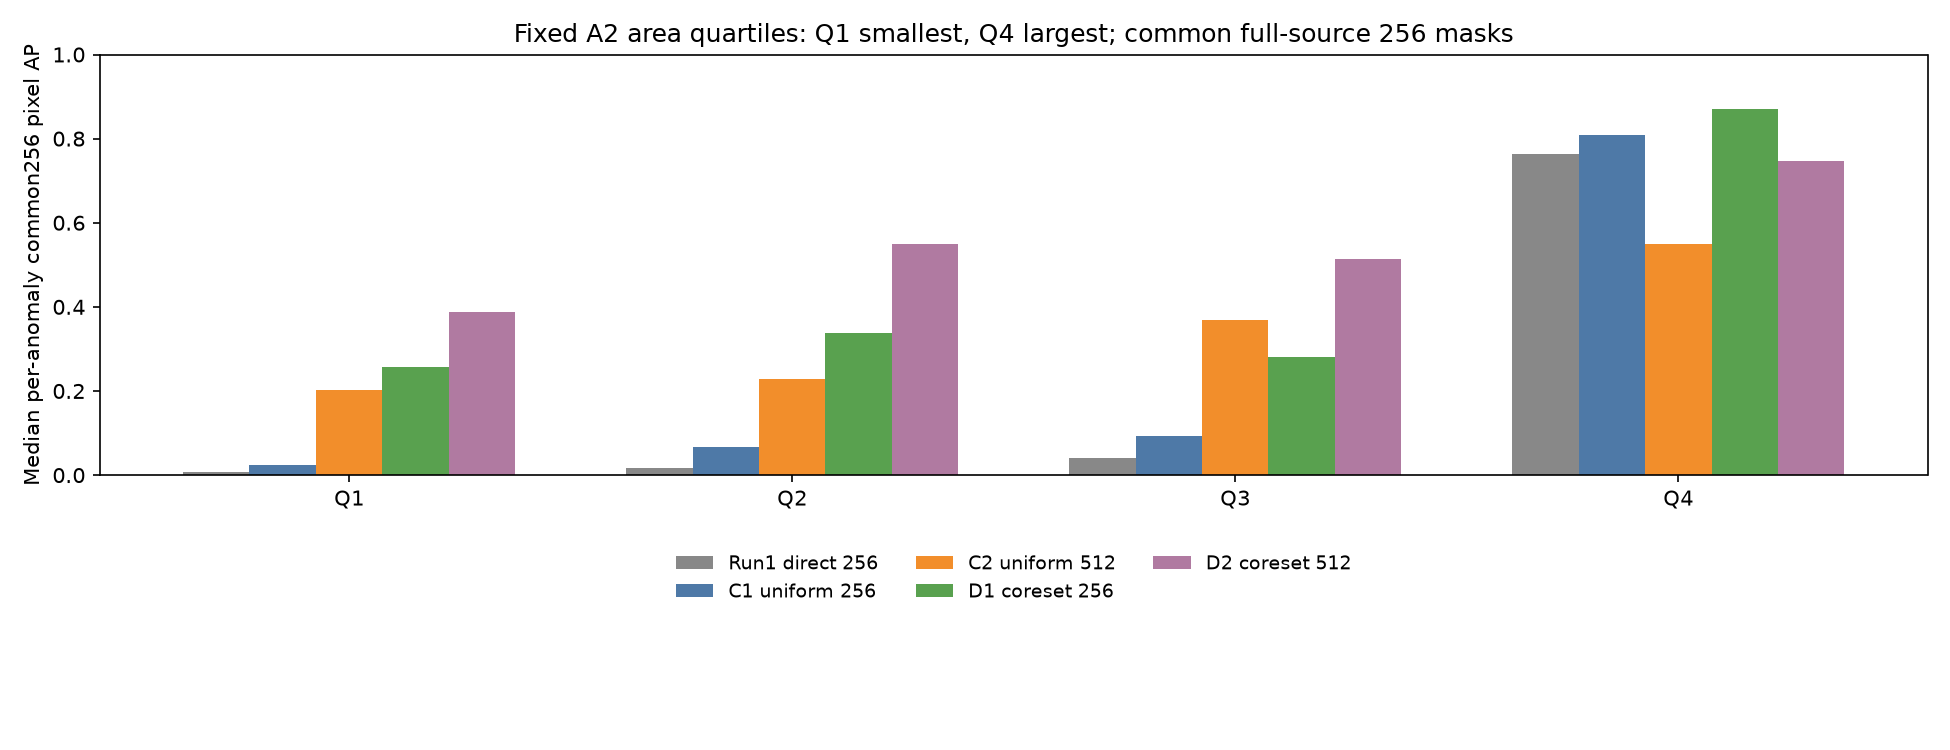

In [3]:
display(pd.read_csv(folder/'type_recall_comparison.csv'))
display(Image(filename=str(folder/'type_recall.png')))
display(pd.read_csv(folder/'size_localization_comparison.csv'))
display(Image(filename=str(folder/'size_quartile_localization.png')))

## Memory coverage is a measured sample, not a causal explanation

The 2,048 query positions per resolution were fixed using seed 44 before anomaly
outcomes. The uniform and coreset banks share those fitting-normal queries.
Distances are evaluated in the original 384-dimensional Euclidean scoring space.
Query positions can coincide with selected references; self-membership and exact
zero counts are reported. These are descriptive fitting-data coverage checks,
not independent normal-validation performance.

Read typical distances and upper-tail distances separately: a lower 95th percentile
or maximum can coexist with a higher mean or median. Padding-center fractions are
geometric proxies, not complete receptive-field support. Neither a smaller padding
fraction nor wider source-image representation proves detector improvement.

,recipe,size,independent_direct_distance_queries_checked,maximum,mean,median,p95,quantile_method,query_count,query_selected_reference_count,zero_distance_convention,zero_distance_fraction
0,C1 uniform256,256,16,2.083445,0.935544,0.971037,1.517133,linear,2048,10,"Exactly zero, no tolerance band",0.004883
1,D1 coreset256,256,16,1.659477,1.163217,1.192209,1.423848,linear,2048,11,"Exactly zero, no tolerance band",0.005371
2,C2 uniform512,512,16,2.370107,1.033679,1.122055,1.709510,linear,2048,4,"Exactly zero, no tolerance band",0.001953
3,D2 coreset512,512,16,1.983875,1.360981,1.412591,1.614994,linear,2048,3,"Exactly zero, no tolerance band",0.001465


,recipe,size,padding_center_proxy_fraction,reference_count,selected_duplicate_indices,unique_source_images,per_image_count,per_image_includes_zero_reference_images,per_image_maximum,per_image_mean,per_image_median,per_image_minimum,per_image_p95
0,C1 uniform256,256,0.263672,4096,0,720,723,True,14,5.665284,5.0,0,10.0
1,D1 coreset256,256,0.010010,4096,0,667,723,True,50,5.665284,4.0,0,17.0
2,C2 uniform512,512,0.272217,4096,0,719,723,True,14,5.665284,6.0,0,10.0
3,D2 coreset512,512,0.005615,4096,0,691,723,True,35,5.665284,4.0,0,15.0


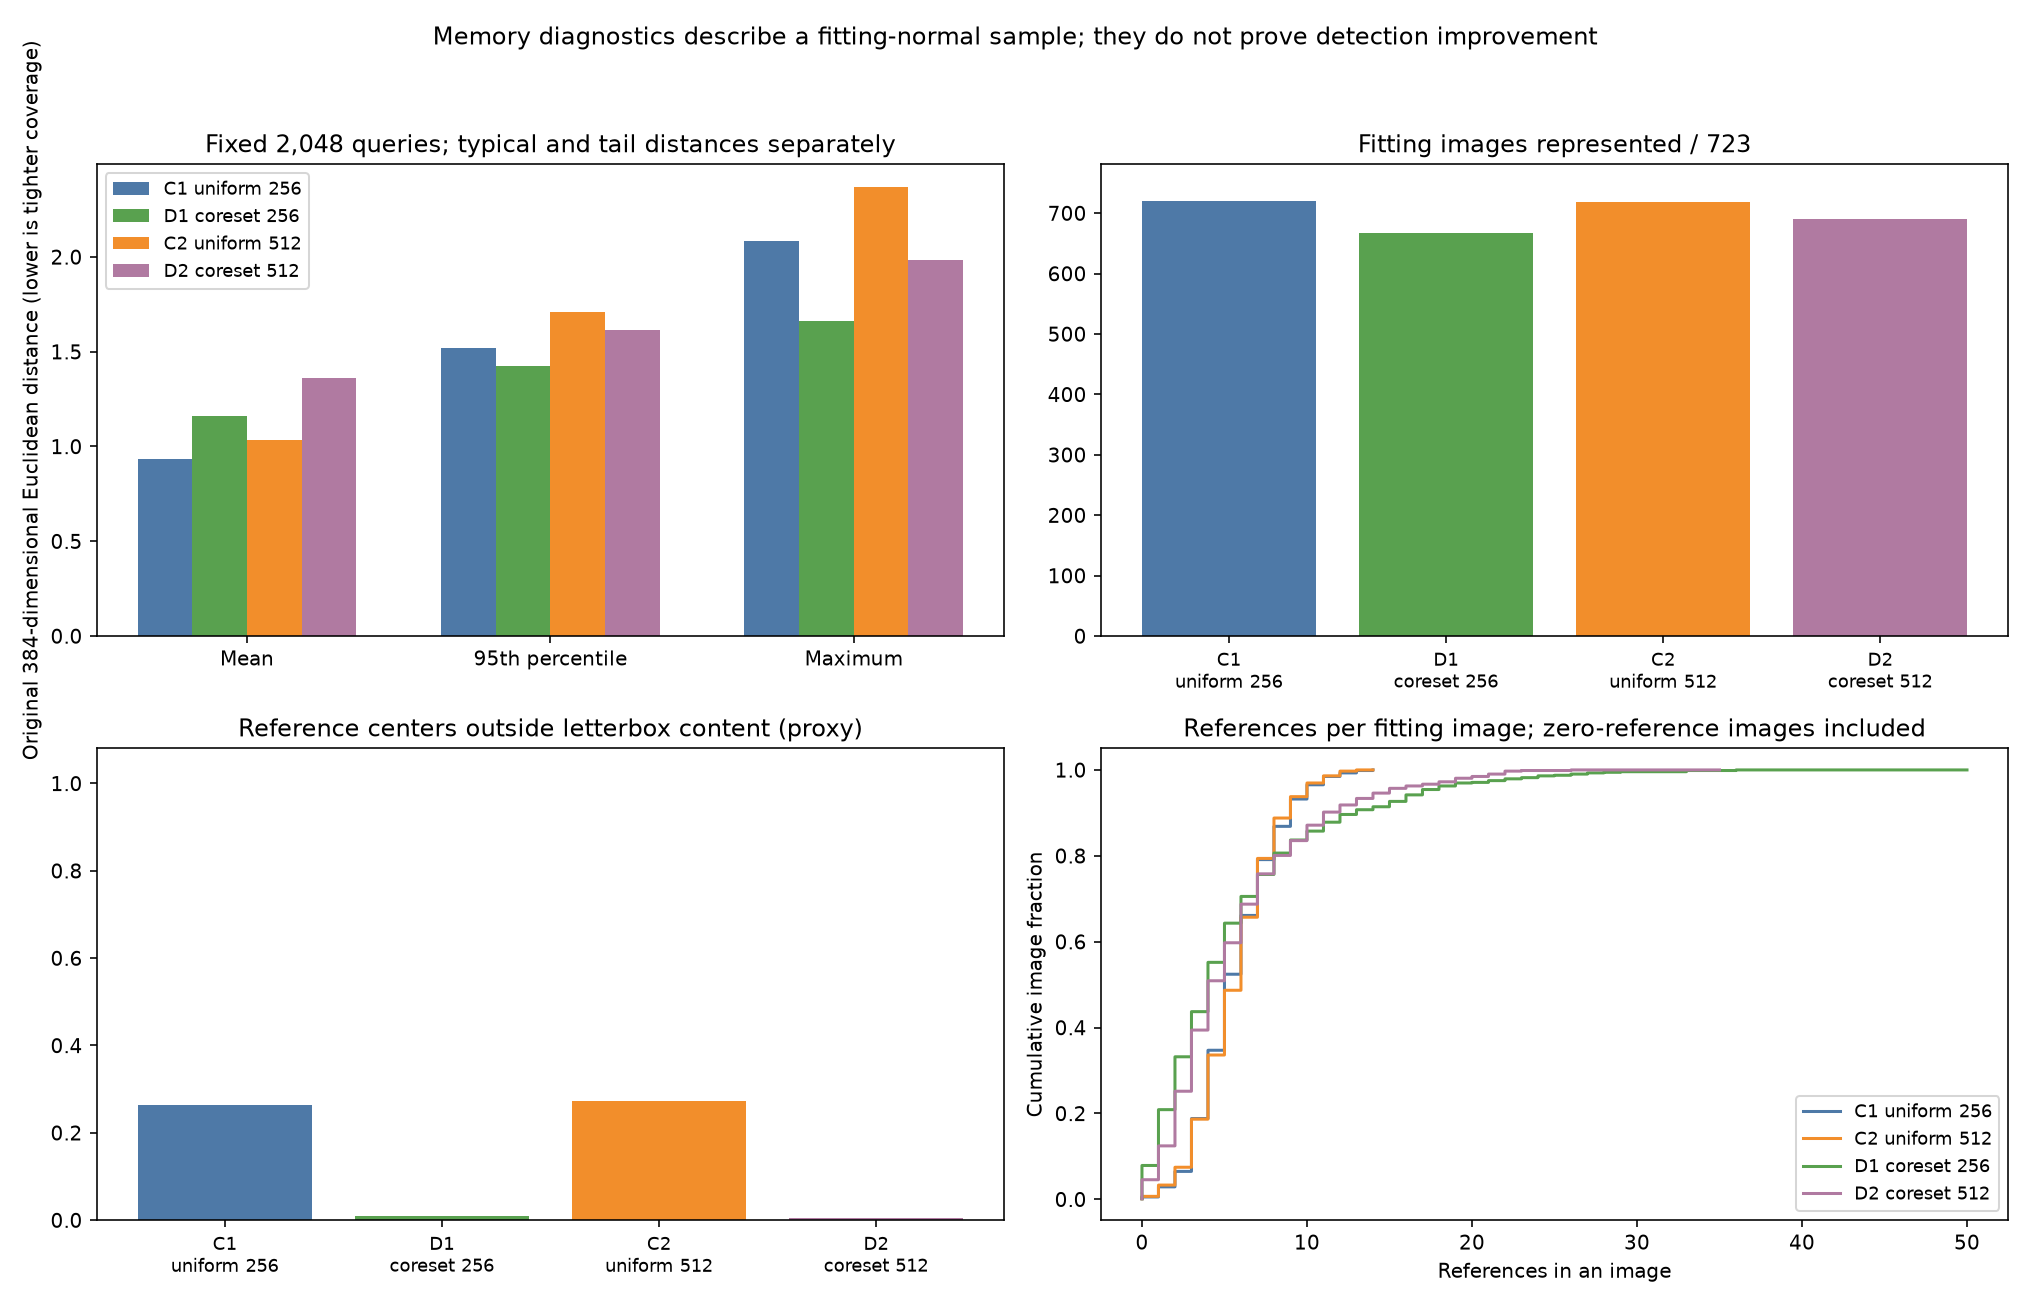

,normalized_crop_region,references,fraction,recipe
0,padding_center,1080,0.263672,C1 uniform256
1,row0_col0,357,0.087158,C1 uniform256
2,row0_col1,319,0.077881,C1 uniform256
3,row0_col2,362,0.088379,C1 uniform256
4,row1_col0,355,0.086670,C1 uniform256
5,row1_col1,298,0.072754,C1 uniform256
6,row1_col2,365,0.089111,C1 uniform256
7,row2_col0,330,0.080566,C1 uniform256
8,row2_col1,286,0.069824,C1 uniform256
9,row2_col2,344,0.083984,C1 uniform256


In [4]:
display(pd.read_csv(folder/'coverage_comparison.csv'))
display(pd.read_csv(folder/'memory_composition.csv'))
display(Image(filename=str(folder/'memory_composition.png')))
display(pd.read_csv(folder/'memory_regions.csv'))

## Resources and score distributions

Preparation includes projection, all 4,096 selections, selected-reference/query
re-extraction, normal calibration and required diagnostics. D2 reuses the verified
normal-only engineering projection cache, but its measured original extraction
cost is charged to the 1,800-second gate; physical current work is recorded separately.
Peak RSS is process high-water memory. Latency is detector processing, without LLMs.

The original pilot excluded raw hashing from reported inference timing; development
includes it. That original-to-development timing comparison is not perfectly matched.
The C↔D comparison uses the same source-processing path.

Raw score distributions are shown separately by recipe and by calibration normals,
development normals and anomalies. Their scales need not coincide across banks.

In [5]:
display(pd.read_csv(folder/'runtime_comparison.csv'))
display(pd.read_csv(folder/'runtime_phases.csv'))
display(pd.read_csv(folder/'score_distribution_summary.csv'))
print('Raw per-image scores:',len(pd.read_csv(folder/'score_distributions.csv')),'saved rows')

,recipe,preparation_seconds,physical_current_preparation_seconds,charged_cached_extraction_seconds,peak_rss_bytes,median_inference_seconds,p95_inference_seconds
0,Run1 direct256,72.491507,72.491507,0.0000,1420705792,0.306921,0.335487
1,C1 uniform256,74.925586,74.925586,0.0000,1691631616,0.291909,0.293628
2,C2 uniform512,239.432922,239.432922,0.0000,1711996928,1.080967,1.100750
3,D1 coreset256,117.955368,117.955369,0.0000,1569046528,0.290946,0.296383
4,D2 coreset512,361.741481,317.125582,44.6159,2334834688,1.080720,1.137649


,recipe,phase,seconds,peak_rss_bytes,projection_sha256,charged_cached_extraction_seconds
0,D1 coreset256,backbone_load,0.890145,520749056,NaN,NaN
1,D1 coreset256,projection,22.412601,713457664,6e1101a4c90b4c4bdf64beeaa4e1e8a57974977b33954e...,0.0000
2,D1 coreset256,selection,18.363469,1046478848,NaN,NaN
3,D1 coreset256,reextraction,21.855682,1046478848,NaN,NaN
4,D1 coreset256,preparation_diagnostics,1.200853,1046478848,NaN,NaN
5,D1 coreset256,calibration,53.033668,1046478848,NaN,NaN
6,D2 coreset512,backbone_load,0.911196,522993664,NaN,NaN
7,D2 coreset512,projection,0.726361,533807104,6e1101a4c90b4c4bdf64beeaa4e1e8a57974977b33954e...,44.6159
8,D2 coreset512,selection,72.511407,2334834688,NaN,NaN
9,D2 coreset512,reextraction,43.171906,2334834688,NaN,NaN


,recipe,group,count,mean,median,std,p90,p95,p99,fraction_above_threshold
0,C1 uniform256,calibration_normal,181,1.958034,1.909528,0.160311,2.229699,2.260681,2.298958,0.049724
1,C1 uniform256,development_anomaly,100,2.484816,2.315180,0.436732,3.201760,3.481456,3.746981,0.610000
2,C1 uniform256,development_normal,100,1.994277,1.944122,0.183499,2.232258,2.246087,2.358855,0.040000
3,C2 uniform512,calibration_normal,181,2.418266,2.375189,0.163860,2.672282,2.716464,2.794346,0.049724
4,C2 uniform512,development_anomaly,100,2.895141,2.783371,0.303365,3.381844,3.548910,3.758859,0.700000
5,C2 uniform512,development_normal,100,2.462462,2.421691,0.194194,2.734814,2.753879,2.908569,0.120000
6,D1 coreset256,calibration_normal,181,1.643691,1.632225,0.075098,1.735855,1.783695,1.865033,0.049724
7,D1 coreset256,development_anomaly,100,2.269181,2.113332,0.526377,3.071392,3.327465,3.712547,0.890000
8,D1 coreset256,development_normal,100,1.664221,1.650736,0.108130,1.727456,1.763055,2.147710,0.040000
9,D2 coreset512,calibration_normal,181,1.896516,1.885880,0.072624,1.989159,2.028992,2.110651,0.049724


Raw per-image scores: 1905 saved rows


## The same eleven examples throughout development

These IDs and selection reasons were fixed in A2 before C1/C2 and D1/D2 outcomes.
They include strong/weak localization, near/low-score misses, small regions,
source defect types and normal false alarms. They were not selected to favor a bank.

The first columns show the original whole-source view and annotation at common 256.
Cyan outlines the unchanged annotation on each map. Display values are raw map
divided by that recipe's pixel threshold, clipped 0–2; the metric computation uses
raw scores. Compare uniform and coreset within each resolution first.

,image_id,reasons
0,de611bce473c840af8adafcd,"[""TP: strongest per-image localization""]"
1,ca6517206c7ed606f1334b73,"[""TP: weakest per-image localization""]"
2,d974322eff775a646b101f0e,"[""FN: nearest below image threshold""]"
3,ef6143041222529aa5aaae7c,"[""FN: lowest image score""]"
4,d513967cbf2cbf166191b214,"[""Smallest-area quartile""]"
5,d9a35e62add18f84d5fe6ab2,"[""bent: middle score-ranked image""]"
6,cf0b7d2b92f0fb2e900016bc,"[""melt: middle score-ranked image""]"
7,f8c75b3d35149a713c6f9194,"[""missing: middle score-ranked image""]"
8,06a000c3b7f783f28804f8a4,"[""scratch: middle score-ranked image""]"
9,122c351f4783e562322ae0b4,"[""FP: middle score-ranked normal""]"


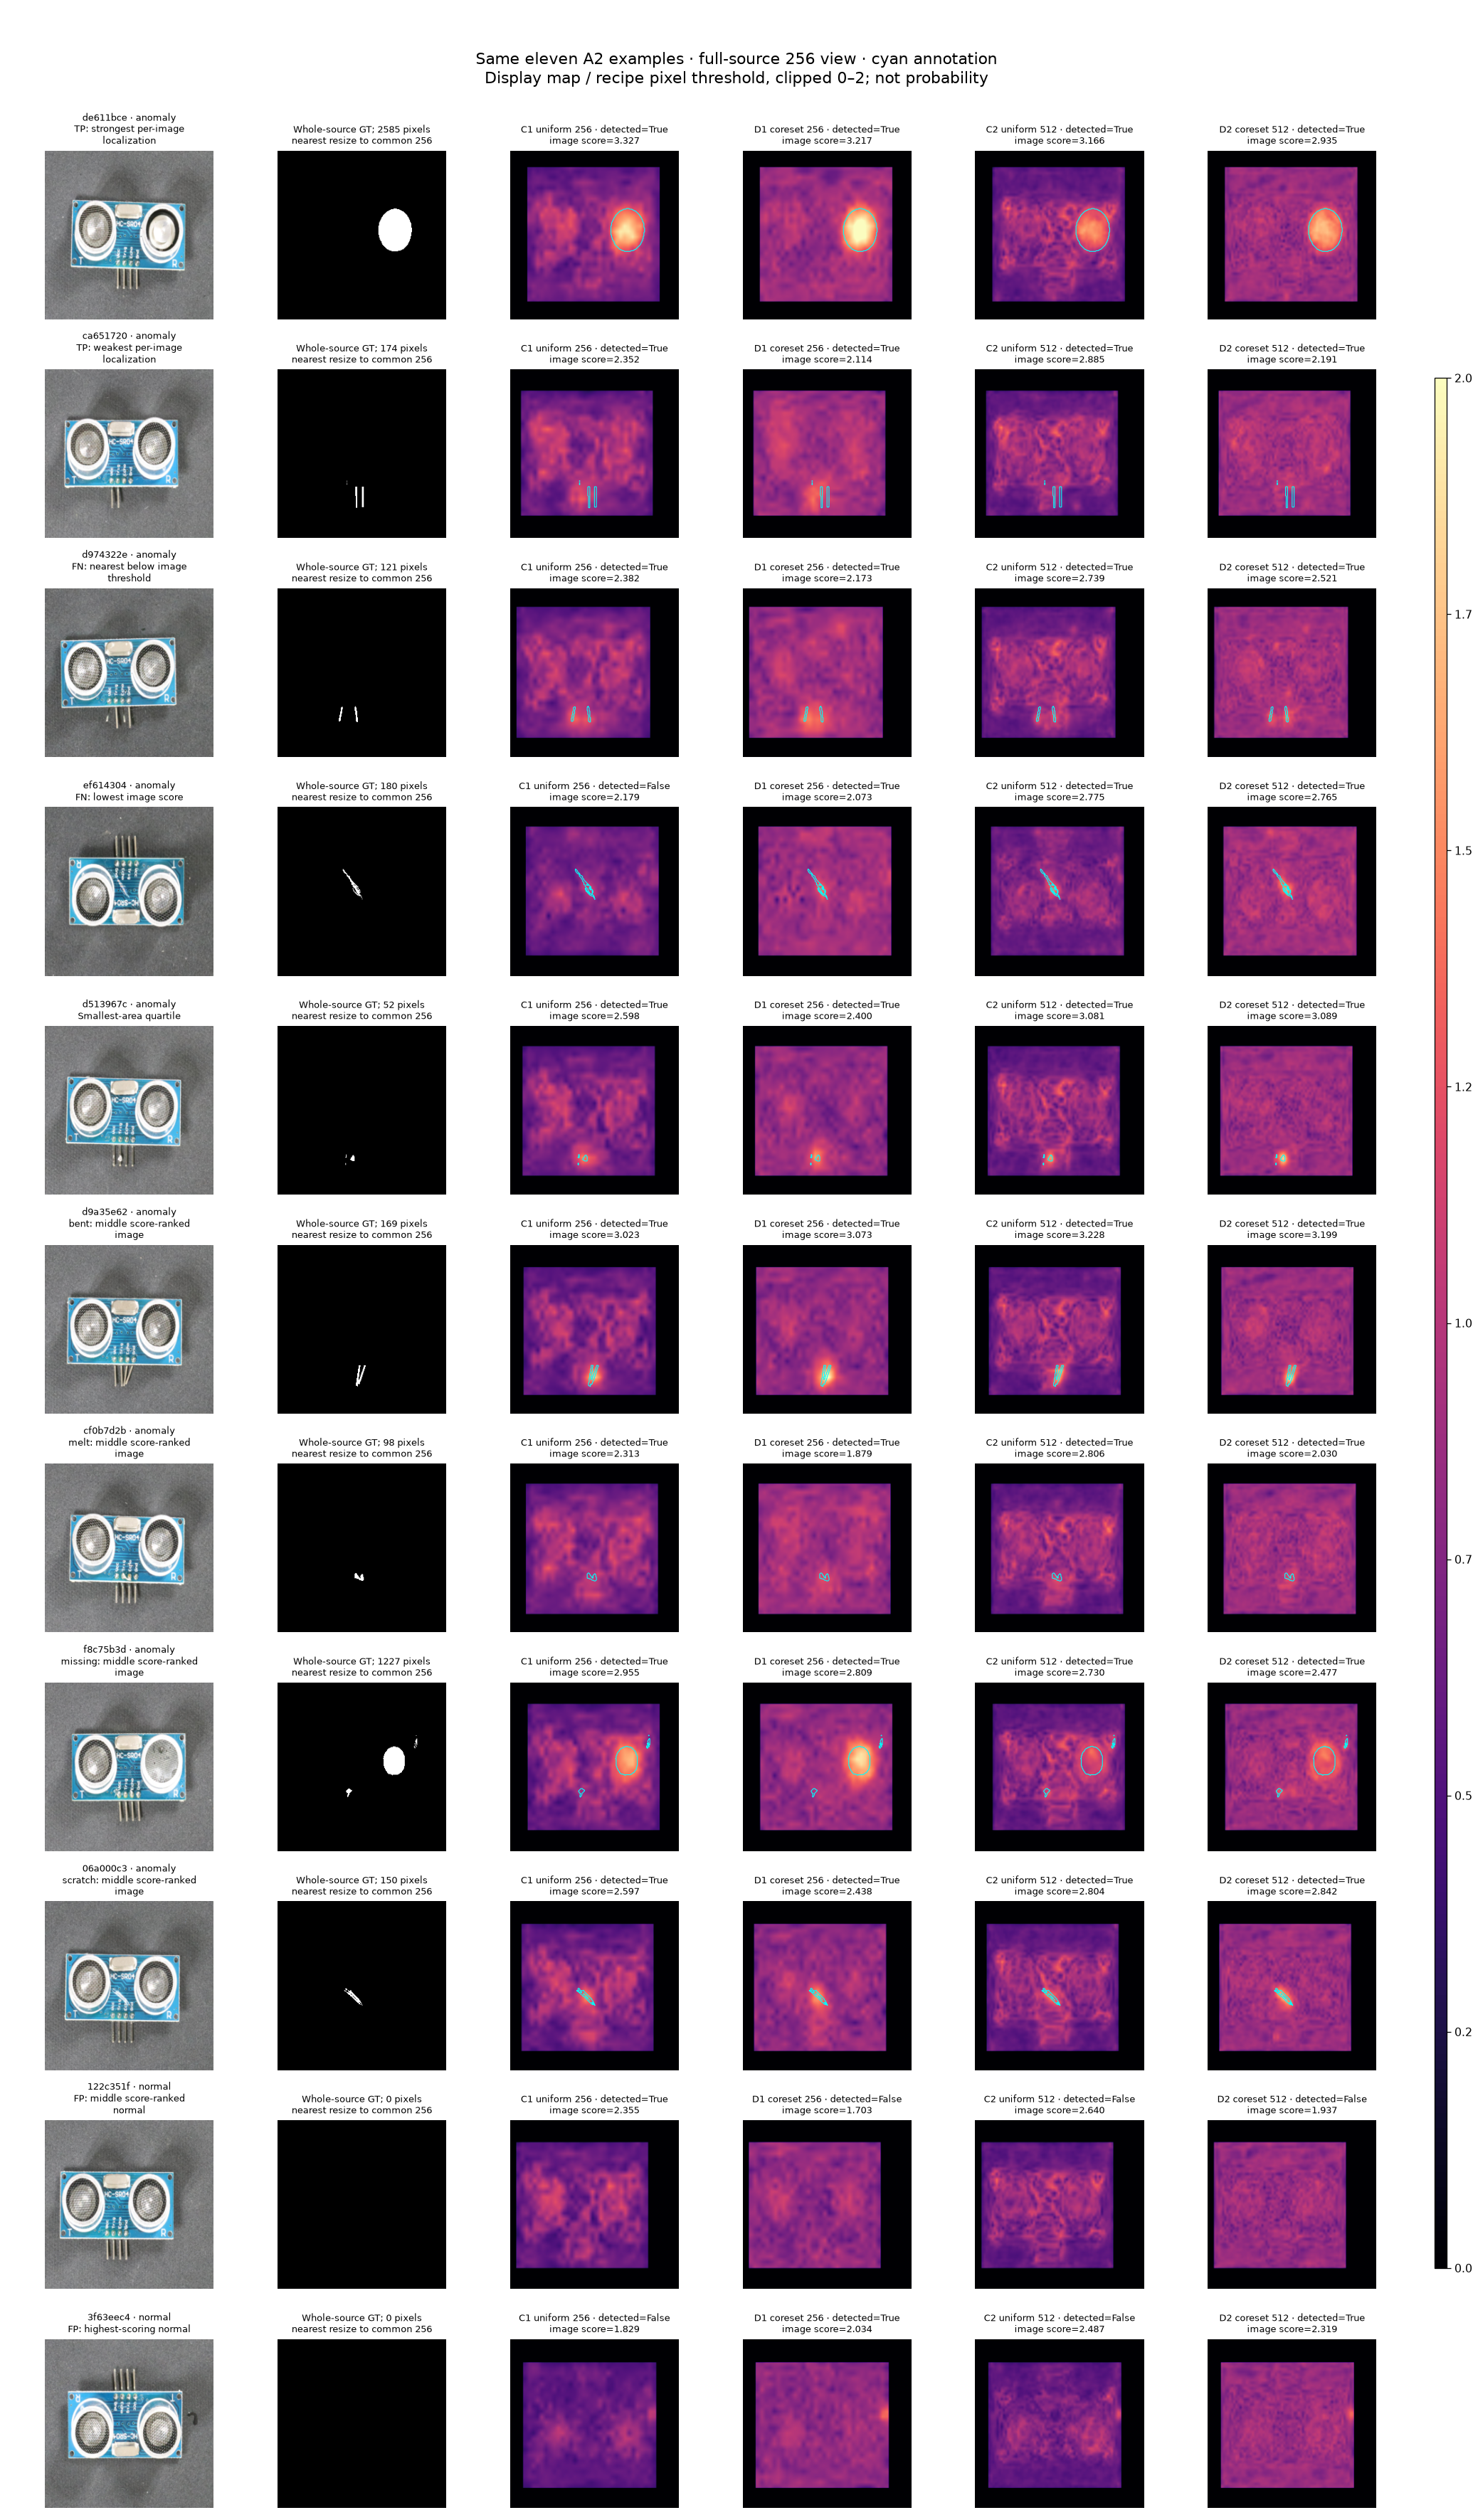

,recipe,image_id,label,score,detected,common_mask_pixels,pixel_ap,peak_inside,reasons
0,C1 uniform256,de611bce473c840af8adafcd,anomaly,3.327227,True,2585,0.978963,True,"[""TP: strongest per-image localization""]"
1,D1 coreset256,de611bce473c840af8adafcd,anomaly,3.216987,True,2585,0.987812,True,"[""TP: strongest per-image localization""]"
2,C2 uniform512,de611bce473c840af8adafcd,anomaly,3.165883,True,2585,0.935211,True,"[""TP: strongest per-image localization""]"
3,D2 coreset512,de611bce473c840af8adafcd,anomaly,2.935478,True,2585,0.993442,True,"[""TP: strongest per-image localization""]"
4,C1 uniform256,ca6517206c7ed606f1334b73,anomaly,2.351753,True,174,0.010093,False,"[""TP: weakest per-image localization""]"
5,D1 coreset256,ca6517206c7ed606f1334b73,anomaly,2.114278,True,174,0.035296,False,"[""TP: weakest per-image localization""]"
6,C2 uniform512,ca6517206c7ed606f1334b73,anomaly,2.885439,True,174,0.006568,False,"[""TP: weakest per-image localization""]"
7,D2 coreset512,ca6517206c7ed606f1334b73,anomaly,2.190782,True,174,0.005821,False,"[""TP: weakest per-image localization""]"
8,C1 uniform256,d974322eff775a646b101f0e,anomaly,2.381501,True,121,0.242591,True,"[""FN: nearest below image threshold""]"
9,D1 coreset256,d974322eff775a646b101f0e,anomaly,2.172792,True,121,0.114543,False,"[""FN: nearest below image threshold""]"


In [6]:
display(pd.read_csv(folder/'qualitative_selection.csv'))
display(Image(filename=str(folder/'fixed_a2_qualitative.png')))
display(pd.read_csv(folder/'qualitative_metrics.csv'))

## Evidence limits and the next decision

This study tests one projected approximate greedy selector, one projection and
one 4,096-reference budget on already-exposed PCB1 development data. A positive
result cannot establish that memory selection was the only bottleneck; a negative
result cannot rule out other selectors or memory budgets. ResNet18, whole-board
resolution, unregistered pose and geometry-specific limitations remain.

The complete recipe and category-adaptation procedure must be frozen before fresh
PCB2 confirmation. PCB2 is not accessed by this notebook. Application/UI and LLM
layers remain deferred until a detector is worth demonstrating.